# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10



🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 1 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3568s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


# 2 Visualize Sample Images

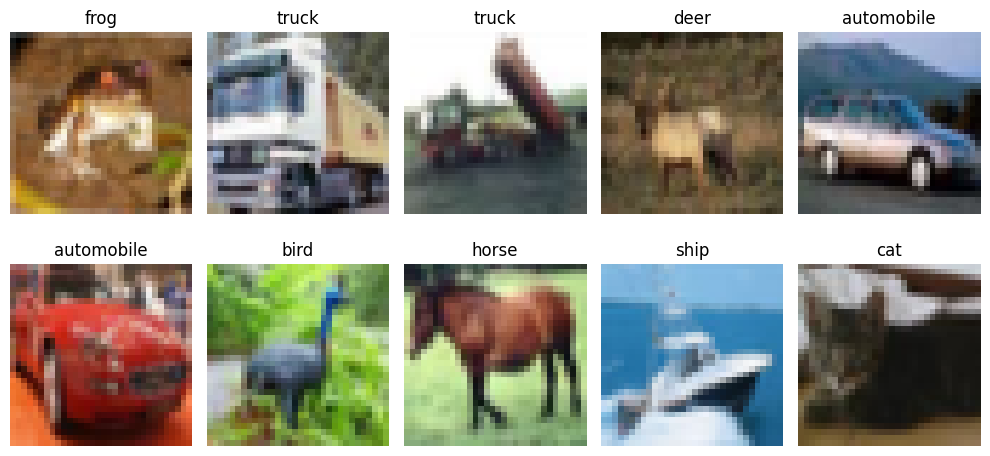

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 3 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2709 - loss: 1.9912 - val_accuracy: 0.3474 - val_loss: 1.8293
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3231 - loss: 1.8587 - val_accuracy: 0.3434 - val_loss: 1.7933
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3409 - loss: 1.8063 - val_accuracy: 0.3852 - val_loss: 1.7341
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3506 - loss: 1.7800 - val_accuracy: 0.3606 - val_loss: 1.7552
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3658 - loss: 1.7506 - val_accuracy: 0.3776 - val_loss: 1.7237
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3699 - loss: 1.7361 - val_accuracy: 0.3904 - val_loss: 1.7028
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3746 - loss: 1.7201 - val_accuracy: 0.4092 - val_loss: 1.6762
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3829 - loss: 1.7026 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4114 - loss: 1.6421
ANN Test Accuracy: 0.4113999903202057


### ANN Model Performance Analysis

The ANN achieved a **test accuracy of approximately 41.14%** on the CIFAR-10 dataset.

Since the ANN operates on **flattened image vectors**, it loses important **spatial information** present in images, such as:

- Edges
- Textures
- Shapes
- Object structures

As a result, the network cannot effectively capture visual patterns and relationships between neighboring pixels. This limitation reduces its ability to learn meaningful image features, leading to **lower classification performance** compared to convolutional neural networks (CNNs), which are specifically designed for image data.

#  Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 107ms/step - accuracy: 0.4590 - loss: 1.5148 - val_accuracy: 0.4422 - val_loss: 1.5982
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.5940 - loss: 1.1549 - val_accuracy: 0.6006 - val_loss: 1.1431
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6602 - loss: 0.9756 - val_accuracy: 0.6074 - val_loss: 1.1259
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.7043 - loss: 0.8510 - val_accuracy: 0.7020 - val_loss: 0.8672
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.7342 - loss: 0.7631 - val_accuracy: 0.6748 - val_loss: 0.9388
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.7629 - loss: 0.6758 - val_accuracy: 0.6460 - val_loss: 1.0460
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 107ms/step - accuracy: 0.7866 - loss: 0.6083 - val_accuracy: 0.6480 - val_loss: 1.1265
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 108ms/step - accuracy: 0.8067 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6846 - loss: 1.0482
CNN Test Accuracy: 0.6845999956130981


### CNN Model Performance Analysis

The CNN achieved a **test accuracy of 68.46%**, significantly outperforming the ANN model, which achieved 41.14%.

CNNs preserve the spatial structure of images and learn hierarchical visual features through convolution operations. The convolutional layers automatically detect:

- Edges
- Textures
- Shapes
- Complex object patterns

Additionally, the use of **Batch Normalization** and **Max Pooling** improves training stability and feature extraction efficiency.

Compared to the ANN, the CNN demonstrated a substantial improvement of approximately **27.32 percentage points**, highlighting the effectiveness of convolutional architectures for image classification tasks such as CIFAR-10.

# 4 Compare Learning Curves

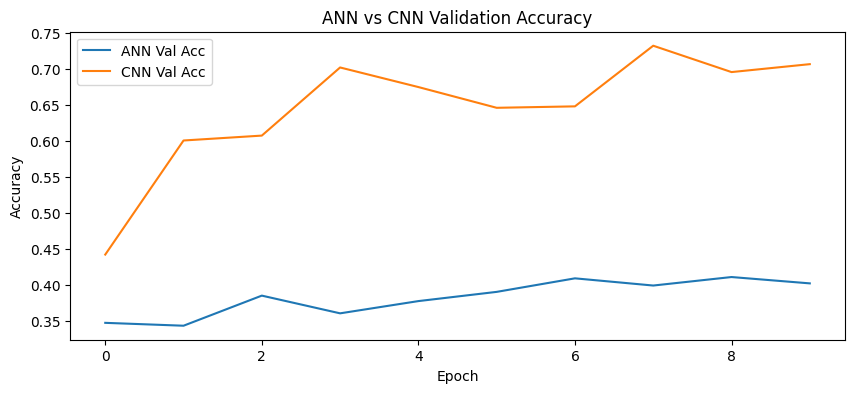

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

### ANN vs CNN Validation Accuracy Comparison

The validation accuracy curves clearly demonstrate that the CNN outperformed the ANN throughout the training process.

The ANN showed slow and limited improvement, reaching a validation accuracy of approximately 40%. Since ANN processes flattened image vectors, it cannot effectively capture spatial relationships between pixels.

In contrast, the CNN rapidly improved and achieved validation accuracies above 70%. Convolutional layers successfully extracted important visual features such as edges, textures, and object shapes, resulting in significantly better image classification performance.

The comparison highlights the superiority of CNN architectures over traditional ANN models for computer vision tasks such as CIFAR-10 image classification.

# 5 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

## Step 1 EarlyStopping Configuration

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Step 2 Enhanced CNN Architecture with Data Augmentation

To improve model generalization and classification performance, an enhanced CNN architecture was developed using data augmentation techniques and additional convolutional layers.

The model incorporates:

- RandomFlip for horizontal image flipping
- RandomRotation for rotation-based augmentation
- RandomZoom for scale variation
- Three convolutional layers with 32, 64, and 128 filters
- Batch Normalization for stable training
- Max Pooling for dimensionality reduction
- Dropout for regularization

This enhanced architecture is expected to achieve better performance and reduce overfitting compared to the baseline CNN model.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 3 Training Enhanced CNN with Early Stopping

In [23]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.6739 - loss: 0.9306 - val_accuracy: 0.7102 - val_loss: 0.8333
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.6910 - loss: 0.8887 - val_accuracy: 0.6816 - val_loss: 0.8955
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.6942 - loss: 0.8718 - val_accuracy: 0.7088 - val_loss: 0.8352
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.7067 - loss: 0.8409 - val_accuracy: 0.7264 - val_loss: 0.8181
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.7142 - loss: 0.8218 - val_accuracy: 0.6910 - val_loss: 0.9239
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.7169 - loss: 0.8116 - val_accuracy: 0.7196 - val_loss: 0.8475
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7268 - loss: 0.7852 - val_accuracy: 0.7278 - val_loss: 0.8255


## Step 4 Evaluation of Enhanced CNN Model

In [25]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_teste
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7169 - loss: 0.8429
Augmented CNN Test Accuracy: 0.7168999910354614


# 6 Performance Comparison Table

## ANN vs CNN Performance Coparision

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4114
1,CNN,0.6846


## Final Model Performance comparision

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4114
1,CNN,0.6846
2,Augmented CNN,0.7169


# 7 Validation Accuracy Comparison of All Models

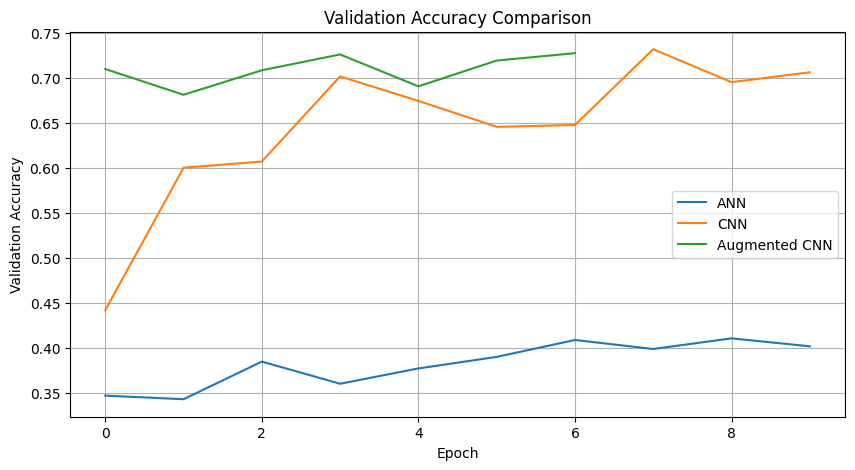

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Enhanced CNN with Data Augmentation Analysis

An enhanced CNN model was developed using data augmentation techniques and a deeper convolutional architecture.

The model incorporated:

- RandomFlip
- RandomRotation
- RandomZoom
- Three convolutional layers with 32, 64, and 128 filters
- Batch Normalization
- Dropout Regularization
- Early Stopping

The enhanced model achieved a test accuracy of approximately **71.69%**, outperforming the baseline CNN model (68.46%) and the ANN model (41.14%).

Data augmentation improved the model's ability to generalize by exposing it to different variations of the training images. The deeper architecture and additional regularization techniques further improved feature extraction and reduced overfitting.

# 8 Conclusion

In this project, image classification models were developed and evaluated on the CIFAR-10 dataset using both Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs).

The ANN achieved a test accuracy of **41.14%**, demonstrating the limitations of fully connected networks when handling image data. Since ANN models operate on flattened image vectors, they lose important spatial information present in images.

The CNN significantly improved performance, achieving a test accuracy of **68.46%** by effectively learning spatial features such as edges, textures, and object shapes through convolution operations.

An enhanced CNN model with data augmentation, additional convolutional layers, Batch Normalization, Dropout, and Early Stopping achieved the best performance with a test accuracy of **71.69%**.

The results clearly demonstrate that CNN-based architectures are more effective than traditional ANNs for image classification tasks, and that data augmentation and regularization techniques further improve model generalization and performance.